**THIS FILE CONTAINS ALL SKILL EXPERIMAENTS:-**


> EXP 1:-Data loading,



Import necessary libraries

In [ ]:
import pandas as pd
import numpy as np

#data visualisation libraries
import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
#to get interactive widgets used in graph drop down menu
from ipywidgets import interact
import ipywidgets as widgets

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
#to ignore warnings
import warnings
warnings.filterwarnings('ignore')
#Information Gain
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif
#chi square test
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
#Feature Importance using Random Forests
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score


2.Load the dataset


# For x = df.iloc[:, :-1] (Features/Independent Variables)

df: Your DataFrame (table of data).

iloc: Selects data by position (rows & columns).

[:, :-1]:
: → Select all rows.
:-1 → Select all columns except the last one


---

**Purpose: Stores all columns except the last one in x (features for prediction).**


---


# For y = df.iloc[:, -1] (Target/Dependent Variable)

df: Your DataFrame.

iloc: Selects data by position.

[:, -1]:
: → Select all rows.
-1 → Select only the last column.

Purpose: Stores the last column in y (target variable to predict).


---


Summary
x: Contains features (used to predict).
y: Contains target (what we predict).
Common preprocessing step in machine learning.




In [ ]:
# Load dataset
diabetic_data = pd.read_csv('/content/drive/MyDrive/DATASETS/diabetes.csv')
df = pd.DataFrame(diabetic_data)
df
# Extract features and target
x=df.iloc[:,:-1]
y=df.iloc[:,-1]


In [ ]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


3.Cleaning the dataset

In [ ]:
display(df.info())
display(df.describe())
display(df.size)
display(df.shape)
display(df.isna().sum())
display(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


None

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


6912

(768, 9)

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df.shape

(768, 9)

In [ ]:
df.dropna()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
df.shape

(768, 9)

Checking outliers using scatter plot

<Axes: >

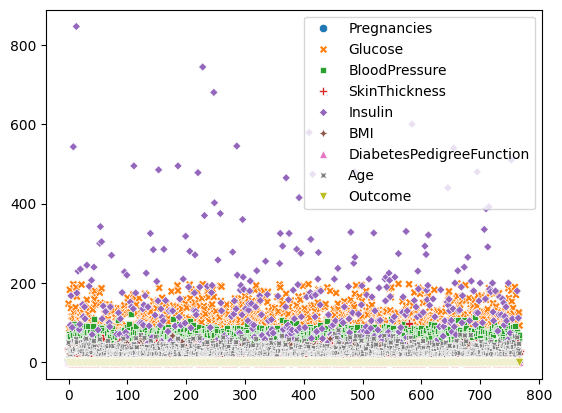

In [ ]:
sns.scatterplot(df)

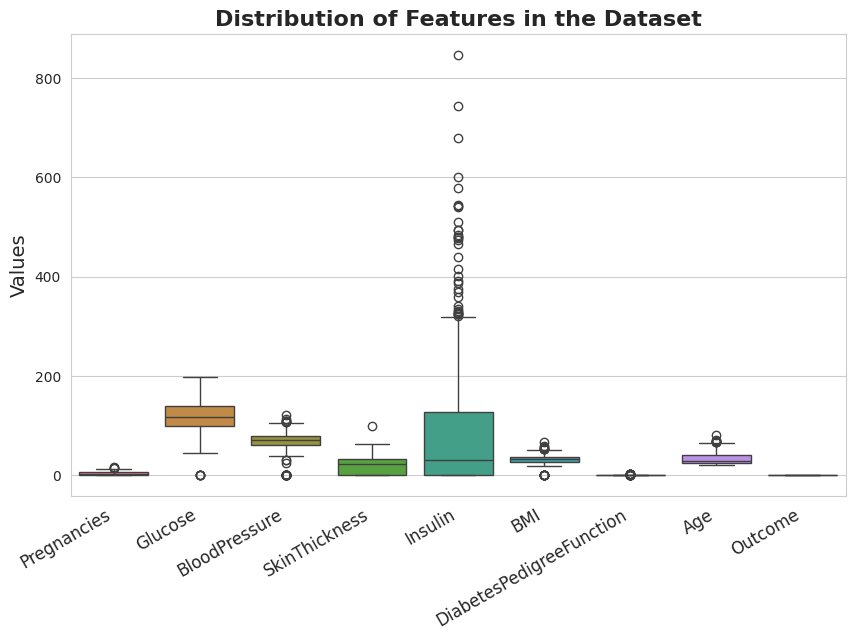

In [ ]:
# Set the style for a clean look
sns.set_style("whitegrid")

# Create the box plot with better aesthetics
plt.figure(figsize=(10, 6))  # Set figure size
ax = sns.boxplot(data=df, palette="husl")  # 'husl' gives distinct colors

# Improve x-axis labels
plt.xticks(rotation=30, ha="right", fontsize=12)  # Rotate labels for readability

# Improve y-axis label
plt.ylabel("Values", fontsize=14)

# Improve title
plt.title("Distribution of Features in the Dataset", fontsize=16, fontweight='bold')

# Show the plot
plt.show()

Methods to remove outliers

In [ ]:
def remove_outliers(df):
    df_clean = df.copy()
    initial_rows = len(df_clean)

    # Remove outliers for each numeric column
    for col in df_clean.select_dtypes(exclude=['object']).columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        df_clean = df_clean[(df_clean[col] >= Q1 - 1.5 * IQR) &
                           (df_clean[col] <= Q3 + 1.5 * IQR)]

    # Calculate number of removed rows
    removed = initial_rows - len(df_clean)

    # Print removal statistics
    print(f"Initial rows: {initial_rows}")
    print(f"Rows after removal: {len(df_clean)}")
    print(f"Removed {removed} outliers ({(removed/initial_rows)*100:.2f}% of data)")

    return df_clean

# Apply outlier removal
data = remove_outliers(df)

Initial rows: 768
Rows after removal: 636
Removed 132 outliers (17.19% of data)


Checking numeric and categorical data

In [ ]:
numeric_features = data.select_dtypes(exclude=['object']).columns
categorical_features = data.select_dtypes(include=['object']).columns

print("\nNumeric Features:", list(numeric_features))
print("Categorical Features:", list(categorical_features))


Numeric Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
Categorical Features: []


Label encoding

In [ ]:
numeric_data=data.select_dtypes(exclude=['object'])
categorical_feature=data.select_dtypes(include=['object'])

encoder=LabelEncoder()
for col in categorical_feature.columns:
    df[col]=encoder.fit_transform(categorical_feature[col])

Spliting the data using train test split

In [ ]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=0)

In [ ]:
model=LogisticRegression()
model.fit(xtrain,ytrain)
model.score(xtest,ytest)

0.8246753246753247

Scaling the data

In [ ]:
def scaled_data(df):
    df_copy = df.copy()
    scaler = StandardScaler()
    df_copy[numeric_features] = scaler.fit_transform(df_copy[numeric_features])
    return df_copy
df_scaled = scaled_data(df)

Data Visualization:-
Plotting data using various graphs

In [ ]:
data = remove_outliers(df)
def plotting(typeofplotting):
    if typeofplotting == 'Pairplot':
        # Pairplot is created for all features at once
        sns.pairplot(data, hue='Outcome')
        plt.show()
        return
    plot_features = [col for col in numeric_features if col != 'Outcome']

    n_features = len(plot_features)
    n_rows = (n_features + 1) // 2  # Ceiling division to get number of rows
    n_cols = 2


    # Create figure with subplots for other plot types
    plt.figure(figsize=(15, 4*n_rows))

    for i, col in enumerate(plot_features):
        plt.subplot(n_rows, n_cols, i+1)

        if typeofplotting == 'Histplot':
            sns.histplot(data=data, x=col, hue='Outcome', multiple="layer", alpha=0.5)

        elif typeofplotting == 'Kdeplot':
            sns.kdeplot(data=data, x=col, hue='Outcome')

        elif typeofplotting == 'Boxplot':
            sns.boxplot(data=data, x='Outcome', y=col)

        elif typeofplotting== 'Pairplot':
            sns.pairplot(data=data)

        elif typeofplotting == 'Pieplot':
            plt.pie(data[col].values,labels=data[col].index, autopct='%1.1f%%')

        plt.title(f'{col} Distribution by Outcome')
        plt.xlabel(col if typeofplotting != 'Boxplot' else 'Outcome')
        plt.ylabel('Count' if typeofplotting == 'Histplot' else 'Density' if typeofplotting == 'Kdeplot' else col)

    plt.tight_layout()
    plt.show()

# Create interactive widget
i = interact(
    plotting,
    typeofplotting=widgets.Dropdown(
        options=['Histplot', 'Kdeplot', 'Pairplot', 'Boxplot'],
        description='Plot Type',
        value='Histplot'
    )
)

Initial rows: 768
Rows after removal: 636
Removed 132 outliers (17.19% of data)


interactive(children=(Dropdown(description='Plot Type', options=('Histplot', 'Kdeplot', 'Pairplot', 'Boxplot')…

Using logistic regression after scaling

In [ ]:
model=LogisticRegression()
model.fit(xtrain,ytrain)
model.score(xtest,ytest)

0.8246753246753247

**FEATURE SELECTION**

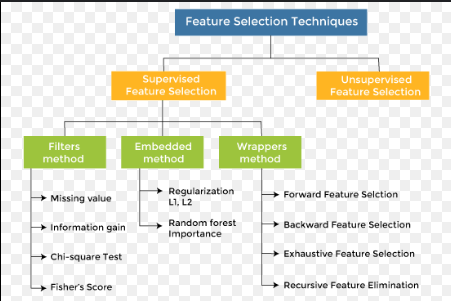

Filter Methods:

> STATISTICAL METHODS

     -a. Perason's Correlation
     -b. Information Gain
     -c. Annova
     -d. Chi-sqaure



> Feature Importance Methods

     -a. Random Forest Feature Importance
     -b. PermutationFeature Importance





**a. Pearson's Correlation**

Pearson’s correlation coefficient is a statistical measure that shows the strength and direction of a linear relationship between two variables.

It gives values between -1 and +1:
*   +1 means a perfect positive linear relationship (when one increases, the other increases).
*   -1 means a perfect negative linear relationship (when one increases, the other decreases).
*   0 means no linear relationship.







✅ Purpose in Data Science

Pearson correlation helps us identify features that are strongly related to the target variable.

It also helps detect highly correlated features with each other (multicollinearity), which can cause problems for models like linear regression.

Features that are highly correlated (close to +1 or -1) with each other might be redundant, so we can drop one of them to simplify the model without losing information.

In [ ]:
correlation_matrix=df.corr(method='pearson')
correlation_matrix

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


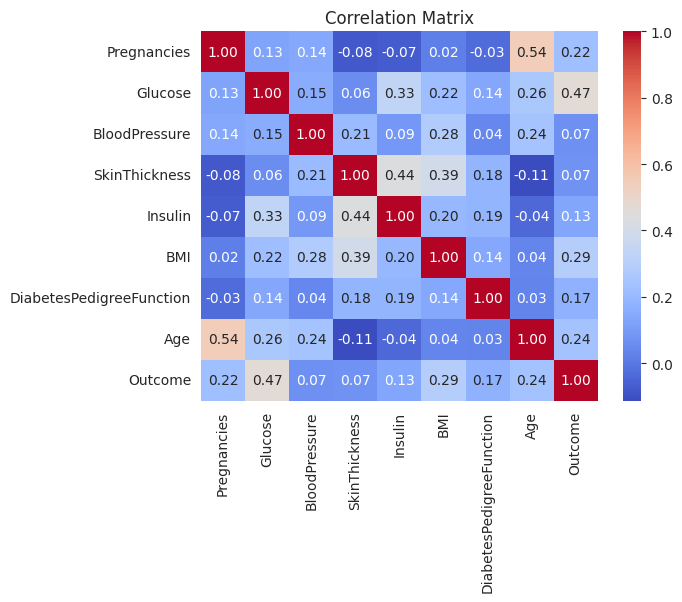

In [ ]:
#plotting
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

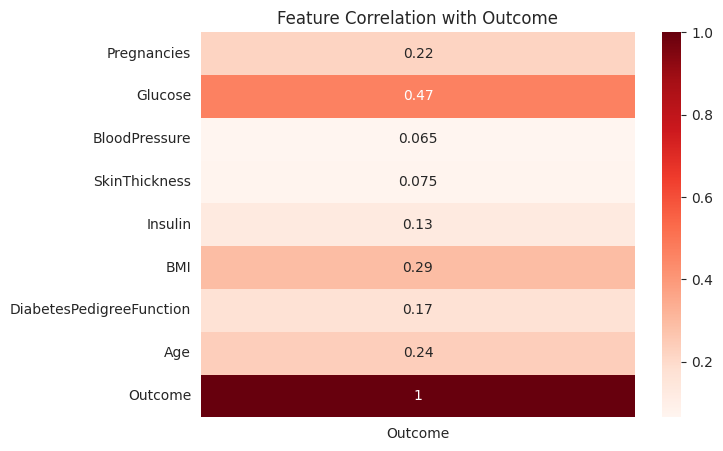

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df is already loaded and contains your dataset
X = df.drop(columns=['Outcome'])  # Exclude the target column
y = df['Outcome']  # Extract target variable
feature_names = X.columns  # Get feature names

# Create a new DataFrame with features and target
data = df.copy()  # No need to recreate from X, just use df

# Compute Pearson's correlation with the target variable
target_correlation = data.corr()[['Outcome']]

# Plot heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(target_correlation, annot=True, cmap=plt.cm.Reds)
plt.title("Feature Correlation with Outcome")
plt.show()


In [ ]:
X = X.drop(columns=['Insulin'])
X

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,33.6,0.627,50
1,1,85,66,29,26.6,0.351,31
2,8,183,64,0,23.3,0.672,32
3,1,89,66,23,28.1,0.167,21
4,0,137,40,35,43.1,2.288,33
...,...,...,...,...,...,...,...
763,10,101,76,48,32.9,0.171,63
764,2,122,70,27,36.8,0.340,27
765,5,121,72,23,26.2,0.245,30
766,1,126,60,0,30.1,0.349,47


In [ ]:
# Set correlation threshold (e.g., 0.2)
THRESHOLD = 0.2

# Compute Pearson correlation matrix
correlation_matrix = df.corr(method='pearson')

# Replace NaN values with 0 (if they persist)
correlation_matrix = correlation_matrix.fillna(0)

# Filter correlations based on threshold
strong_correlations = correlation_matrix[abs(correlation_matrix) >= THRESHOLD]

# Print filtered correlation matrix
print("Features with strong correlations (Threshold =", THRESHOLD, "):")
print(strong_correlations)

Features with strong correlations (Threshold = 0.2 ):
                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000       NaN            NaN            NaN   
Glucose                           NaN  1.000000            NaN            NaN   
BloodPressure                     NaN       NaN       1.000000       0.207371   
SkinThickness                     NaN       NaN       0.207371       1.000000   
Insulin                           NaN  0.331357            NaN       0.436783   
BMI                               NaN  0.221071       0.281805       0.392573   
DiabetesPedigreeFunction          NaN       NaN            NaN            NaN   
Age                          0.544341  0.263514       0.239528            NaN   
Outcome                      0.221898  0.466581            NaN            NaN   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies                    NaN       NaN                 

**What causes NaN?**
The Pearson correlation coefficient is calculated using the formula: r = cov(x, y) / (std_dev(x) * std_dev(y)). If either std_dev(x) or std_dev(y) is zero (meaning the standard deviation of one of the variables is zero, indicating no variability), the denominator becomes zero, resulting in a division by zero, which is undefined and represented as NaN.


**What does it mean?**
A NaN correlation coefficient signifies that the relationship between the two variables cannot be meaningfully assessed using the Pearson correlation method because one of the variables is constant.



> b .INFORMATION GAIN



In [ ]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import SelectKBest

# Assuming df is already loaded and contains your dataset
X = df.drop(columns=['Outcome'])  # Exclude the target column
y = df['Outcome']  # Extract target variable
# Select all features and calculate Information Gain
selector = SelectKBest(score_func=mutual_info_classif, k='all')
selector.fit(X, y)

feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Information Gain (Mutual Info)': selector.scores_
})

# Sort features by Information Gain
sorted_features = feature_scores.sort_values(by='Information Gain (Mutual Info)', ascending=False)

# Display the sorted features
print(sorted_features)

                    Feature  Information Gain (Mutual Info)
1                   Glucose                        0.117868
5                       BMI                        0.086462
7                       Age                        0.053105
0               Pregnancies                        0.046466
2             BloodPressure                        0.035290
3             SkinThickness                        0.028067
4                   Insulin                        0.022069
6  DiabetesPedigreeFunction                        0.012067



**Purpose of k='all':**

You’re telling SelectKBest not to drop anything.
It simply computes and shows scores for all features.
You can use this to just rank and inspect, without filtering.





> c. ANNOVA FEATURE SELECTION METHOD

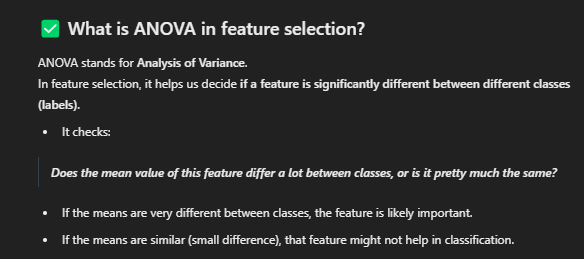

In [ ]:
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import SelectKBest

# Assuming df is already loaded and contains your dataset
x = df.drop(columns=['Outcome'])  # Exclude the target column
y = df['Outcome']  # Extract target variable


selector=SelectKBest(score_func=f_classif,k='all')
selector.fit(x,y)
#get p values that is probability value
p_values=selector.pvalues_
#print p values
print(p_values)
#select the features with p values below significant level eg(0.05)
significant_features=xtrain.columns[selector.get_support()]
significant_features

[5.06512730e-10 8.93543165e-43 7.15139001e-02 3.83477048e-02
 2.86186460e-04 1.22980749e-16 1.25460701e-06 2.20997546e-11]


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')



>d. CHI-SQUARE FILTER SELECTION METHOD



Chi-squared test helps you find features that are related to the target variable by looking at how often their values appear together.

High χ² value = likely relationship = good feature for prediction.

Low χ² value = likely no relationship = less important feature.
Basically, it helps you pick the most useful features for your machine learning model.

In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
selector = SelectKBest(score_func=chi2, k='all')  # k='all' to get scores for all features
selector.fit(X, y)
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Chi-Square Score': selector.scores_
})

# Sort features by Chi-Square score
sorted_features = feature_scores.sort_values(by='Chi-Square Score', ascending=False)

# Display the sorted features
print(sorted_features)

                    Feature  Chi-Square Score
4                   Insulin       2175.565273
1                   Glucose       1411.887041
7                       Age        181.303689
5                       BMI        127.669343
0               Pregnancies        111.519691
3             SkinThickness         53.108040
2             BloodPressure         17.605373
6  DiabetesPedigreeFunction          5.392682


**FEATURE IMPORTANCE METHODS**

**Definition of Feature Importance:**

Feature importance is a technique in data science that helps identify which features (input variables) in a dataset contribute the most to the prediction made by a machine learning model. In simple terms, it tells us which columns of data are most useful in making accurate decisions.

**Explanation of Feature Importance:**

Feature importance helps us understand which features in a dataset are most useful for making accurate predictions. It shows which features have the strongest influence on the model’s output and which features are less important. For example, when predicting house prices, features like location and number of rooms might be very important, while the color of the door might not matter. Knowing feature importance helps in simplifying the model by removing unnecessary features, making it faster, more efficient, and easier to explain. It also allows data scientists to focus on the key drivers behind the model’s decisions and communicate the model’s behavior clearly.

**Types of Feature Importance:**

Built-in Feature Importance:

1.   Built-in Feature Importance:
Some models, like Decision Trees, Random Forests, and XGBoost, automatically calculate feature importance based on how often and how effectively a feature splits the data.

2.   Some models, like Decision Trees, Random Forests, and XGBoost, automatically calculate feature importance based on how often and how effectively a feature splits the data.


3.   Permutation Feature Importance:
This method involves randomly shuffling the values of one feature and measuring how much the model’s prediction accuracy decreases. A large drop in accuracy means the feature is important.

4.   SHAP (SHapley Additive exPlanations):
SHAP values explain how much each feature contributes to each prediction, providing a detailed, fair, and consistent explanation of feature importance for every individual prediction.


5.   Coefficients (in Linear Models):
In linear models, feature importance is indicated by the size of the coefficients — larger absolute values of coefficients mean greater importance of that feature in predicting the outcome.










> a. Random Forest Feature Importance




*   It comes from the model’s internal attributes (like Gini importance or mean decrease impurity).
*   The model itself “learns” which features are important during training.
*   👉 This is an Embedded Method — because the feature selection is performed as part of the model learning process itself.




Training Score: 1.0
Testing Score: 0.7792207792207793


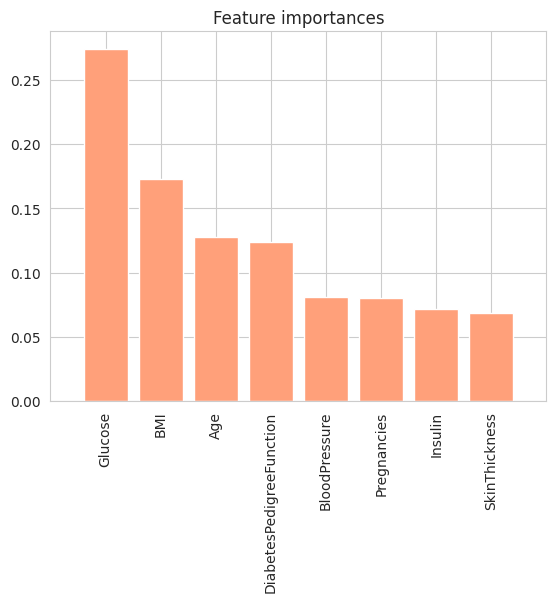

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
import matplotlib.pyplot as plt

X = df.drop(columns=['Outcome'])
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
rf = RandomForestClassifier(n_estimators = 100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

print("Training Score:",rf.score(X_train,y_train))
print("Testing Score:",rf.score(X_test,y_test))

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure()
plt.title("Feature importances")
plt.bar(range(X_train.shape[1]), importances[indices],
        color="lightsalmon", align="center")
plt.xticks(range(X_train.shape[1]), X.columns[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.show()

In [ ]:
#classification Report
sfm = SelectFromModel(rf, threshold=0.06)
sfm.fit(X_train, y_train)
X_important_train = sfm.transform(X_train)
X_important_test = sfm.transform(X_test)
rf = RandomForestClassifier(n_estimators = 100, class_weight='balanced', random_state=42)
rf.fit(X_important_train, y_train)
y_pred = rf.predict(X_important_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.87      0.84       100
           1       0.72      0.61      0.66        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154





> Permutation Feature Importance



Training Score: 0.9641693811074918
Testing Score: 0.974025974025974


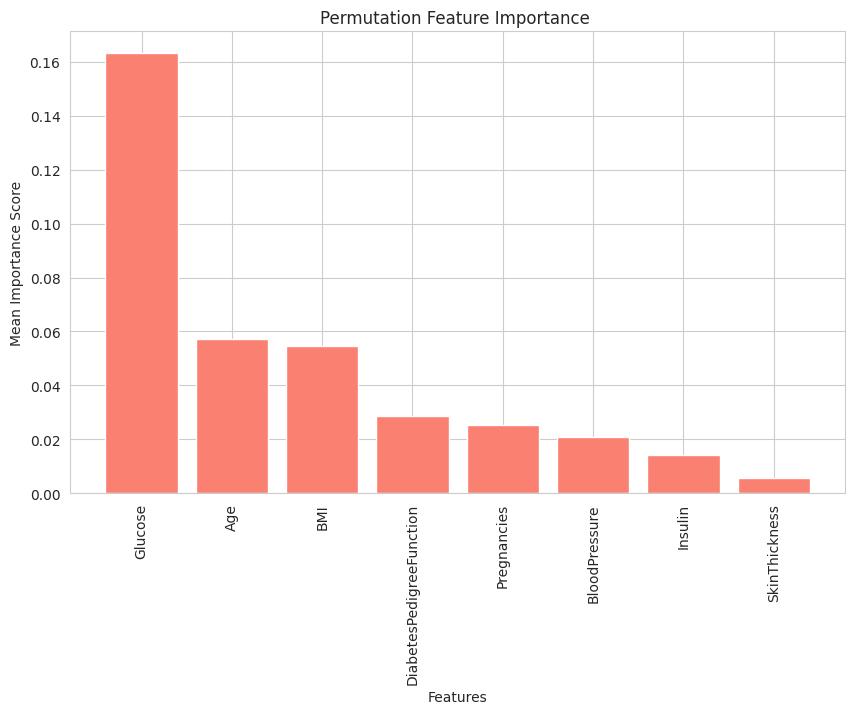

Top features by permutation importance:

                    Feature  Importance
0                   Glucose    0.162987
1                       Age    0.057143
2                       BMI    0.054545
3  DiabetesPedigreeFunction    0.028571
4               Pregnancies    0.025325
5             BloodPressure    0.020779
6                   Insulin    0.014286
7             SkinThickness    0.005844


In [ ]:
from sklearn.inspection import permutation_importance


# 5. Train a Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(xtrain, ytrain)

print("Training Score:",rf.score(X_train,y_train))
print("Testing Score:",rf.score(X_test,y_test))

# 6. Apply permutation feature importance on the test set
result = permutation_importance(rf, xtest, ytest, n_repeats=10, random_state=42)

# 7. Get sorted indices based on importance
sorted_indices = result.importances_mean.argsort()[::-1]

# 8. Plot the permutation feature importance
plt.figure(figsize=(10, 6))
plt.title("Permutation Feature Importance ")
plt.bar(range(x.shape[1]), result.importances_mean[sorted_indices], color='salmon')
plt.xticks(range(x.shape[1]), x.columns[sorted_indices], rotation=90)
plt.ylabel("Mean Importance Score")
plt.xlabel("Features")
plt.show()

# 9. Print top features in order
permutation_importance_ranking = pd.DataFrame({
    'Feature': x.columns[sorted_indices],
    'Importance': result.importances_mean[sorted_indices]
})
print("Top features by permutation importance:\n")
print(permutation_importance_ranking)


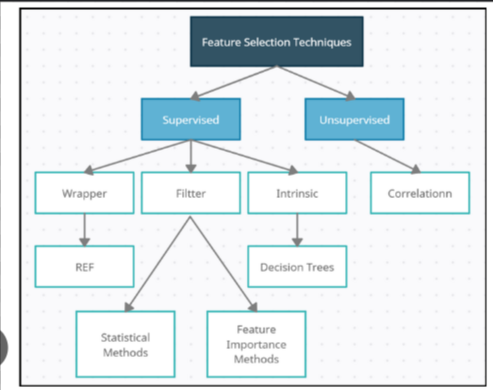

**2.Wrapper methods**



> a.Recursive Funtion Elemination

> b.Forward Feature selection

> c.Backward Feature Selection

> d.Exhaustive Feature Selection












In [ ]:
#recursive funtion elimination(using logistic regression)
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

def reftest(scalled_x,y):
    model = LogisticRegression(max_iter=1000)


    selector = RFE(estimator=model, n_features_to_select=10, step=1)
    X_selected = selector.fit_transform(scalled_x,y)

    selected_features = scalled_x.columns[selector.support_]
    print("Selected features:", selected_features.tolist())


    feature_ranking = pd.DataFrame({
        'Feature': scalled_x.columns,
        'Ranking': selector.ranking_
    })
    feature_ranking = feature_ranking.sort_values('Ranking')
    print("\nFeature ranking (1 = selected, higher = eliminated earlier):")
    print(feature_ranking)



In [ ]:
scalled_x = df_scaled  # Assign the scaled data to the variable expected by 'reftest'
reftest(scalled_x, y)

Selected features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Feature ranking (1 = selected, higher = eliminated earlier):
                    Feature  Ranking
0               Pregnancies        1
1                   Glucose        1
2             BloodPressure        1
3             SkinThickness        1
4                   Insulin        1
5                       BMI        1
6  DiabetesPedigreeFunction        1
7                       Age        1
8                   Outcome        1


b.Forward Feature Selection

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from sklearn.linear_model import LogisticRegression
# Use your regular feature matrix (no need to scale for RandomForest)
# X = df.drop('Outcome', axis=1)
# y = df['Outcome']

selected_features = []
model = LogisticRegression()
num_features_to_select = 5

while len(selected_features) < num_features_to_select:
    best_score = -1
    best_feature = None

    for feature_idx in range(X.shape[1]):
        if feature_idx in selected_features:
            continue

        candidate_features = selected_features + [feature_idx]
        candidate_feature_names = X.columns[candidate_features]

        scores = cross_val_score(model, X.loc[:, candidate_feature_names], y, cv=5, scoring='accuracy')

        # Use the first fold score instead of mean
        score = scores[0]

        if score > best_score:
            best_score = score
            best_feature = feature_idx

    if best_feature is not None:
        selected_features.append(best_feature)
        print(f"Selected Feature {len(selected_features)}: {X.columns[best_feature]}, Score (Fold 1): {best_score:.4f}")

print("Selected feature indices:", selected_features)
print("Selected feature names:", X.columns[selected_features].tolist())


Selected Feature 1: Glucose, Score (Fold 1): 0.7078
Selected Feature 2: BMI, Score (Fold 1): 0.7727
Selected Feature 3: BloodPressure, Score (Fold 1): 0.7792
Selected Feature 4: Insulin, Score (Fold 1): 0.7792
Selected Feature 5: SkinThickness, Score (Fold 1): 0.7792
Selected feature indices: [1, 5, 2, 4, 3]
Selected feature names: ['Glucose', 'BMI', 'BloodPressure', 'Insulin', 'SkinThickness']


b.Backward Feature selection

In [ ]:


from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import numpy as np

# Replace this with your dataset and labels
X = scalled_x  # Replace with your feature matrix
y = df['Outcome']

# Define the machine learning model (in this case, a Random Forest Classifier)
model = LogisticRegression()

# Initialize a list with all feature indices
all_features = list(range(X.shape[1]))

# Define the minimum number of features you want to retain
min_features_to_retain = 5

while len(all_features) > min_features_to_retain:
    worst_score = 1.0  # Initialize with a high value
    worst_feature = None

    for feature_idx in all_features:
        # Create a list of features without the current one
        candidate_features = [f for f in all_features if f != feature_idx]

        # Get column names corresponding to the selected feature indices
        candidate_feature_names = X.columns[candidate_features]

        # Evaluate the model's performance using cross-validation
        # Use .loc to select columns by their names for pandas compatibility
        scores = cross_val_score(model, X.loc[:, candidate_feature_names], y, cv=5, scoring='accuracy')
        mean_score = np.mean(scores)

        # Keep track of the worst-performing feature
        if mean_score < worst_score:
            worst_score = mean_score
            worst_feature = feature_idx

    if worst_feature is not None:
        all_features.remove(worst_feature)
        print(f"Removed Feature: {worst_feature}, Mean Accuracy: {worst_score:.4f}")

print("Remaining feature indices:", all_features)

Removed Feature: 8, Mean Accuracy: 0.7709
Removed Feature: 1, Mean Accuracy: 0.6992
Removed Feature: 5, Mean Accuracy: 0.6719
Removed Feature: 0, Mean Accuracy: 0.6524
Remaining feature indices: [2, 3, 4, 6, 7]


c.Exhaustive search

In [ ]:
from itertools import combinations
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import numpy as np

X = scalled_x  # Replace with your feature matrix
y = df['Outcome']

# Define the machine learning model (in this case, a Random Forest Classifier)
model = LogisticRegression()

# Define the maximum number of features to be selected
max_features = 5

# Initialize variables to keep track of the best feature subset and its accuracy
best_subset = None
best_accuracy = 0.0

# Generate all possible combinations of feature indices
all_feature_combinations = list(combinations(range(X.shape[1]), max_features))

for feature_subset in all_feature_combinations:
    feature_subset = list(feature_subset)

    # Evaluate the model's performance using cross-validation
    # Use .iloc for integer-location based indexing to select columns
    scores = cross_val_score(model, X.iloc[:, feature_subset], y, cv=5, scoring='accuracy')

    # Use only the first fold's score (instead of the mean accuracy)
    score = scores[0]

    # Check if this feature subset is better than the best one found so far
    if score > best_accuracy:
        best_accuracy = score
        best_subset = feature_subset

print("Best Feature Subset:", best_subset)
print("Best Accuracy (Fold 1):", best_accuracy)


Best Feature Subset: [0, 1, 2, 3, 8]
Best Accuracy (Fold 1): 1.0


**3.Embedded methods**



*   Regularization


> LASSO regrassion



> Ridge Regression




*   Tree Based algorithms


> Decision Tree



> Random Forest











Regularisation


>1.LASSO




In [ ]:
from sklearn.linear_model import LassoCV

from sklearn.model_selection import StratifiedKFold

X = df.drop(columns='Outcome')
y = df['Outcome']
skf = StratifiedKFold(n_splits=10)
lasso = LassoCV(cv=skf, random_state=42).fit(X, y)
print('Selected Features:', list(X.columns[np.where(lasso.coef_!=0)[0]]))

Selected Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [ ]:
from sklearn.linear_model import LassoCV
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import numpy as np

# Assuming X and y are already defined as in your previous cells
skf = StratifiedKFold(n_splits=10)
lasso = LassoCV(cv=skf, random_state=42).fit(X, y)
print('Selected Features:', list(X.columns[np.where(lasso.coef_!=0)[0]]))

lr = LogisticRegression(C=10, class_weight='balanced', max_iter=10000, random_state=42)

# Use .loc or .iloc with appropriate indexing for Pandas DataFrames
selected_features_indices = np.where(lasso.coef_!=0)[0]
preds = cross_val_predict(lr, X.iloc[:, selected_features_indices], y, cv=skf)

print(classification_report(y, preds))

Selected Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
              precision    recall  f1-score   support

           0       0.84      0.77      0.80       500
           1       0.63      0.72      0.67       268

    accuracy                           0.76       768
   macro avg       0.73      0.75      0.74       768
weighted avg       0.77      0.76      0.76       768



In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import numpy as np

# Assuming X and y are already defined as in your previous cells
skf = StratifiedKFold(n_splits=10)

# Remove random_state from RidgeCV
Ridge = RidgeCV(cv=skf).fit(X, y)
print('Selected Features:', list(X.columns[np.where(Ridge.coef_!=0)[0]]))

lr = LogisticRegression(C=10, class_weight='balanced', max_iter=10000, random_state=42)

# Use .loc or .iloc with appropriate indexing for Pandas DataFrames
selected_features_indices = np.where(Ridge.coef_!=0)[0]
preds = cross_val_predict(lr, X.iloc[:, selected_features_indices], y, cv=skf)

print(classification_report(y, preds))

Selected Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
              precision    recall  f1-score   support

           0       0.84      0.77      0.80       500
           1       0.63      0.72      0.67       268

    accuracy                           0.76       768
   macro avg       0.73      0.75      0.74       768
weighted avg       0.77      0.76      0.76       768



**Bagging Algorithms¶**

Bootstrap Aggregation or bagging involves taking multiple samples from your training dataset (with replacement) and training a model for each sample.
The final output prediction is averaged across the predictions of all of the sub-models.

The three bagging models covered in this section are as follows:

1.Bagged Decision Trees

2.Random Fores

3.Extra Trees

bagging-bootstrap classifier

BAGGING

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Assuming X and y are your features and target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # Split data

# Initialize models
tree = DecisionTreeClassifier(random_state=42)
lr = LogisticRegression(random_state=42)
knn = KNeighborsClassifier()

# Train and score individual models
models = [tree, lr, knn]
model_names = ['Decision Tree', 'Logistic Regression', 'K-Nearest Neighbors']
for model, name in zip(models, model_names):
    model.fit(X_train, y_train)
    score1 = model.score(X_test, y_test)
    score2 = model.score(X_train,y_train)
    y_pred = model.predict(X_test)  # Predictions on test data
    print("Testing accuracy:")
    print(f"{name} Accuracy: {score1}\n")

    print("Training accuracy:")
    print(f"{name} Accuracy: {score2}\n")

# Bagging Classifier with Decision Tree as base estimator
bagging_clf = BaggingClassifier(estimator=tree, n_estimators=1500, random_state=42)
bagging_clf.fit(X_train, y_train)
bagging_score = bagging_clf.score(X_test, y_test)
print(f"Bagging Classifier (Decision Tree Base) Accuracy: {bagging_score}")

# Define the evaluate function
def evaluate(model, X_train, X_test, y_train, y_test):
    """Evaluates a model's performance.

    Args:
        model: The trained machine learning model.
        X_train: The training data features.
        X_test: The testing data features.
        y_train: The training data labels.
        y_test: The testing data labels.
    """
    y_pred = model.predict(X_test)  # Predictions on test data

    # Calculate and print accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy}")

    # Print classification report (precision, recall, F1-score)
    print(classification_report(y_test, y_pred))

    # Print confusion matrix
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

evaluate(bagging_clf, X_train, X_test, y_train, y_test)

Testing accuracy:
Decision Tree Accuracy: 0.7467532467532467

Training accuracy:
Decision Tree Accuracy: 1.0

Testing accuracy:
Logistic Regression Accuracy: 0.7467532467532467

Training accuracy:
Logistic Regression Accuracy: 0.7703583061889251

Testing accuracy:
K-Nearest Neighbors Accuracy: 0.6623376623376623

Training accuracy:
K-Nearest Neighbors Accuracy: 0.7980456026058632

Bagging Classifier (Decision Tree Base) Accuracy: 0.7402597402597403
Accuracy: 0.7402597402597403
              precision    recall  f1-score   support

           0       0.81      0.78      0.79        99
           1       0.63      0.67      0.65        55

    accuracy                           0.74       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.74      0.74       154

Confusion Matrix:
[[77 22]
 [18 37]]


In [ ]:
scores = {
    'Bagging Classifier': {
        'Train': accuracy_score(y_train, bagging_clf.predict(X_train)),
        'Test': accuracy_score(y_test, bagging_clf.predict(X_test)),
    },
}

Random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(random_state=42, n_estimators=1000)
rf_clf.fit(X_train, y_train)
evaluate(rf_clf, X_train, X_test, y_train, y_test)

Accuracy: 0.7337662337662337
              precision    recall  f1-score   support

           0       0.80      0.79      0.79        99
           1       0.62      0.64      0.63        55

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154

Confusion Matrix:
[[78 21]
 [20 35]]


In [ ]:
scores['Random Forest'] = {
        'Train': accuracy_score(y_train, rf_clf.predict(X_train)),
        'Test': accuracy_score(y_test, rf_clf.predict(X_test)),
    }

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

ex_tree_clf = ExtraTreesClassifier(n_estimators=1000, max_features=7, random_state=42)
ex_tree_clf.fit(X_train, y_train)
evaluate(ex_tree_clf, X_train, X_test, y_train, y_test)

Accuracy: 0.7402597402597403
              precision    recall  f1-score   support

           0       0.80      0.79      0.80        99
           1       0.63      0.65      0.64        55

    accuracy                           0.74       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.74      0.74      0.74       154

Confusion Matrix:
[[78 21]
 [19 36]]
